# <div style="text-align: center; background-color:#319bad; font-family:newtimeroman; color: white; padding: 14px; line-height: 1;border-radius:20px">Titanic Solutions</div>

![imagem](https://www.cnnbrasil.com.br/wp-content/uploads/sites/12/2022/04/120405051718-titanic-ship-cobh-horizontal-large-gallery-e1649875801989-1.webp?w=876&h=484&crop=1)

<h3 style="text-align: left;background-color:#70d4e6; font-family:newtimeroman; color: white; padding: 14px; line-height: 1; border-radius:10px"> About Dataset</h3>

<h4>Titanic dataset is one of the most famous dataset used for machine learning.<br><br>
The dataset contains 11 columns:<br>
</h4>

* Survived
* Pclass
* Name
* Sex
* Age
* SibSp
* Parch
* Ticket
* Fare
* Cabin
* Embarked

<h3 style="text-align: left; background-color: #70d4e6; font-family:newtimeroman; color: white; padding: 14px; line-height: 1; border-radius:10px">Notebook Objectives</h3>

<h4>The objective is to predict who survived the shipwreck.</h4>

<a id="top"></a>
<div class="list-group" id="list-tab" role="tablist">
    <h3 style="text-align: left; background-color:#319bad; font-family:newtimeroman; color: white; padding: 14px; line-height: 1; border-radius:10px"><b>Table of Contents</b></h3>
    
* [1. Import Necessary Libraries](#1)<br>
   - [1.1 Data Analysis](#1.1)<br>
   - [1.2 Missing Values](#1.2)<br>
   - [1.3 Clear Dataset](#1.3)<br>
* [2. Plots](#2)
* [3. Feature Engineering](#3)
* [4. Model](#4)
* [5. AutoML](#5)    

<a id="1"></a>
# <div style="text-align: center; background-color:#319bad; font-family:newtimeroman; color: white; padding: 14px; line-height: 1;border-radius:20px">1. Import Necessary Libraries</div>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from plotly.offline import iplot
import plotly.graph_objects as go

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set(rc={'figure.figsize':(10,6)})
sns.set(font_scale=1.3)

<a id="1.1"></a>
# <div style="text-align: left; background-color:#70d4e6; font-family:newtimeroman;color: white; padding: 14px; line-height: 1;border-radius:10px">1.1 Data Analysis</div>

In [3]:
train = pd.read_csv('../input/titanic/train.csv')

In [4]:
test = pd.read_csv('/kaggle/input/titanic/test.csv')

In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<a id="1.2"></a>
# <div style="text-align: left; background-color:#70d4e6; font-family:newtimeroman;color: white; padding: 14px; line-height: 1;border-radius:10px">1.2 Missing Values</div>

In [7]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
(train.isnull().sum()/len(train))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [10]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [11]:
(test.isnull().sum()/len(test))*100

PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64

<a id="1.3"></a>
# <div style="text-align: left; background-color:#70d4e6; font-family:newtimeroman;color: white; padding: 14px; line-height: 1;border-radius:10px">1.3 Clear Dataset</div>

In [12]:
train.drop(columns=['Cabin','PassengerId','Name','Ticket'], inplace=True)

In [13]:
avg_f = train[(train['Sex']=='female')]
avg_f['Age'] = avg_f['Age'].fillna(round(avg_f['Age'].mean(),0))

In [14]:
avg_m = train[(train['Sex']=='male')]
avg_m['Age'] = avg_m['Age'].fillna(round(avg_m['Age'].mean(),0)) 

In [15]:
train = pd.concat([avg_m,avg_f])
train = train.sample(frac=1).reset_index(drop=True)

In [16]:
train['Embarked'].fillna(method='ffill', inplace=True)

In [17]:
test.drop(columns=['Cabin','PassengerId','Name','Ticket'], inplace=True)

avg_f = test[(test['Sex']=='female')]
avg_f['Age'] = avg_f['Age'].fillna(round(avg_f['Age'].mean(),0))

avg_m = test[(test['Sex']=='male')]
avg_m['Age'] = avg_m['Age'].fillna(round(avg_m['Age'].mean(),0)) 

test = pd.concat([avg_m,avg_f])
test = test.sample(frac=1).reset_index(drop=True)

test['Embarked'].fillna(method='ffill', inplace=True)

<div style="color:black; background-color:#f5f7b0; border-radius:10px; padding:20px;">
In the age column the missing values were filled in with the average age by sex.<br/>
The Cabin columns has 77.10% of missing values. There are many missing values, so I deleted it.
</div>

In [18]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,1,female,52.0,1,1,93.5000,S
1,1,3,female,28.0,1,0,16.1000,S
2,0,3,male,29.0,0,0,9.4833,S
3,0,3,female,8.0,3,1,21.0750,S
4,0,3,male,31.0,0,0,7.8958,S


<a id="2"></a>
# <div style="text-align: center; background-color:#319bad; font-family:newtimeroman; color: white; padding: 14px; line-height: 1;border-radius:20px">2. Plots</div>

In [19]:
values=train["Survived"].value_counts().values
fig = go.Figure(data=[go.Pie(labels=['Not Survived','Survived'],values=values,textinfo='label+percent')])
fig.update_layout(title={'text': "Titanic Survived",'y':0.9,'x':0.45,'xanchor': 'center','yanchor': 'top'},
                  font=dict(size=18, color='black', family="Courier New, monospace"))

In [20]:
values=train["Pclass"].value_counts().values
fig = go.Figure(data=[go.Pie(labels=['3º Class','2° Class','1° Class'],values=values,textinfo='label+percent')])
fig.update_layout(title={'text': "Class of Ship",'y':0.9,'x':0.45,'xanchor': 'center','yanchor': 'top'},
                  font=dict(size=18, color='black', family="Courier New, monospace"))
fig.show()

In [21]:
values=train["Sex"].value_counts().values
fig = go.Figure(data=[go.Pie(labels=['Male','Female'],values=values,textinfo='label+percent')])
fig.update_layout(title={'text': "Sex",'y':0.9,'x':0.47,'xanchor': 'center','yanchor': 'top'},
                  font=dict(size=18, color='black', family="Courier New, monospace"))
fig.show()

In [22]:
survived = train[train['Survived']==1]
values=survived["Sex"].value_counts().values
fig = go.Figure(data=[go.Pie(labels=['Male','Female'],values=values,textinfo='label+percent')])
fig.update_layout(title={'text': "Survivor by Sex",'y':0.9,'x':0.47,'xanchor': 'center','yanchor': 'top'},
                  font=dict(size=18, color='black', family="Courier New, monospace"))
fig.show()

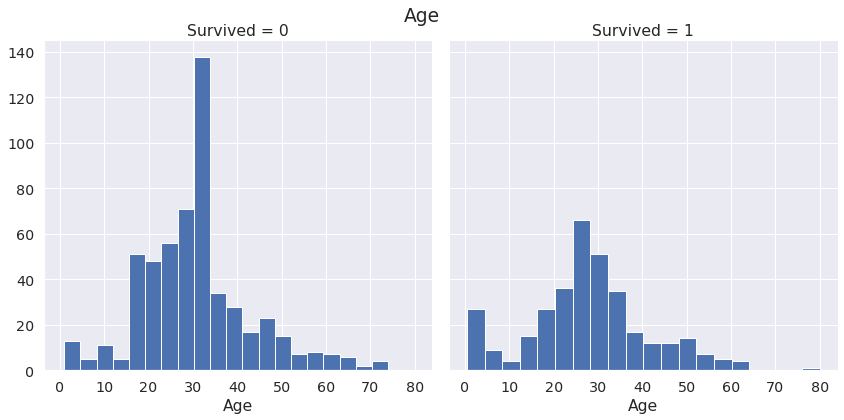

In [23]:
g = sns.FacetGrid(train, col='Survived', height=6)
g.map(plt.hist, 'Age', bins=20)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Age');

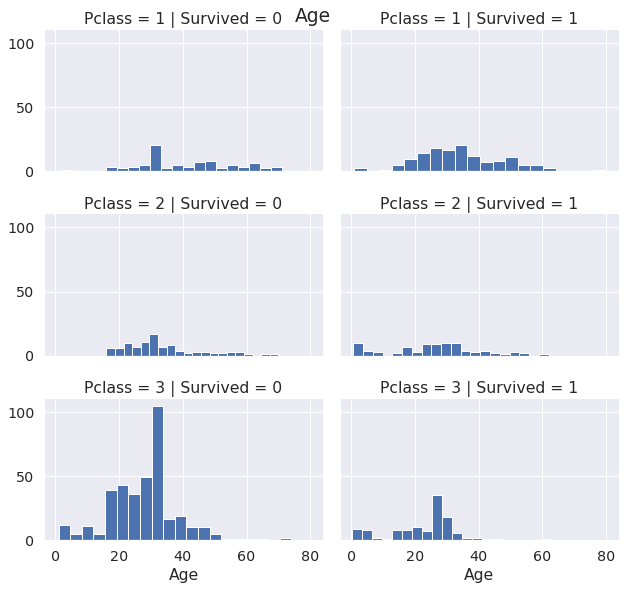

In [24]:
g = sns.FacetGrid(train, col='Survived', row='Pclass', size=2.8, aspect=1.6)
g.map(plt.hist, 'Age', bins=20);
g.fig.suptitle('Age');

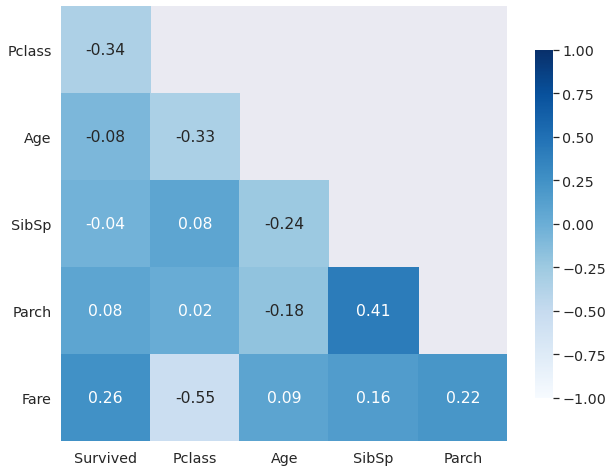

In [25]:
corr = train.corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=np.bool))
mask = mask[1:, :-1]
corr = corr.iloc[1:,:-1].copy()# plot heatmap
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='Blues', vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.yticks(rotation=0)
plt.show()

<a id="3"></a>
# <div style="text-align: center; background-color:#319bad; font-family:newtimeroman; color: white; padding: 14px; line-height: 1;border-radius:20px">3. Feature Engineering</div>

In [26]:
def encoder(data):
    le = LabelEncoder()
    for col in data.select_dtypes('object'):
        data[col] = le.fit_transform(data[col])
    return(data)

In [27]:
train['FareBand'] = pd.qcut(train['Fare'], 4)
train[['FareBand', 'Survived']].groupby(['FareBand'], as_index=False).mean().sort_values(by='FareBand', ascending=True)

,FareBand,Survived
0,"(-0.001, 7.91]",0.197309
1,"(7.91, 14.454]",0.303571
2,"(14.454, 31.0]",0.454955
3,"(31.0, 512.329]",0.581081


In [28]:
train['AgeBand'] = pd.qcut(train['Age'], 5)
train[['AgeBand', 'Survived']].groupby(['AgeBand'], as_index=False).mean().sort_values(by='AgeBand', ascending=True)

,AgeBand,Survived
0,"(0.419, 20.0]",0.458101
1,"(20.0, 28.0]",0.432203
2,"(28.0, 31.0]",0.221053
3,"(31.0, 38.0]",0.458716
4,"(38.0, 80.0]",0.372881


<div style="color:black; background-color:#f5f7b0; border-radius:10px; padding:20px;">
New columns were created in order to improve the model
</div>

In [29]:
train.loc[train['Fare'] <= 7.91, 'Fare'] = 0
train.loc[(train['Fare'] > 7.91) & (train['Fare']<=14.454), 'Fare'] = 1
train.loc[(train['Fare'] > 14.545) & (train['Fare']<=31.0), 'Fare'] = 2
train.loc[train['Fare'] > 31.0, 'Fare'] = 3

In [30]:
train.loc[train['Age'] <= 20, 'Age'] = 0
train.loc[(train['Age'] > 20) & (train['Age'] <= 28), 'Age'] = 1
train.loc[(train['Age'] > 28) & (train['Age'] <= 31), 'Age'] = 2
train.loc[(train['Age'] > 31) & (train['Age'] <= 38), 'Age'] = 3
train.loc[ train['Age'] > 38, 'Age'] = 4

In [31]:
test.loc[test['Fare'] <= 7.91, 'Fare'] = 0
test.loc[(test['Fare'] > 7.91) & (test['Fare']<=14.454), 'Fare'] = 1
test.loc[(test['Fare'] > 14.545) & (test['Fare']<=31.0), 'Fare'] = 2
test.loc[test['Fare'] > 31.0, 'Fare'] = 3


test.loc[test['Age'] <= 20, 'Age'] = 0
test.loc[(test['Age'] > 20) & (test['Age'] <= 28), 'Age'] = 1
test.loc[(test['Age'] > 28) & (test['Age'] <= 31), 'Age'] = 2
test.loc[(test['Age'] > 31) & (test['Age'] <= 38), 'Age'] = 3
test.loc[ test['Age'] > 38, 'Age'] = 4

In [32]:
train = encoder(train)
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FareBand,AgeBand
0,1,1,0,4.0,1,1,3.0,2,"(31.0, 512.329]","(38.0, 80.0]"
1,1,3,0,1.0,1,0,2.0,2,"(14.454, 31.0]","(20.0, 28.0]"
2,0,3,1,2.0,0,0,1.0,2,"(7.91, 14.454]","(28.0, 31.0]"
3,0,3,0,0.0,3,1,2.0,2,"(14.454, 31.0]","(0.419, 20.0]"
4,0,3,1,2.0,0,0,0.0,2,"(-0.001, 7.91]","(28.0, 31.0]"


In [33]:
test = encoder(test)
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,2,1,1.0,0,0,1.0,2
1,3,0,3.0,0,2,1.0,2
2,3,1,1.0,0,0,2.0,2
3,1,1,4.0,0,0,2.0,2
4,3,1,1.0,0,0,1.0,2


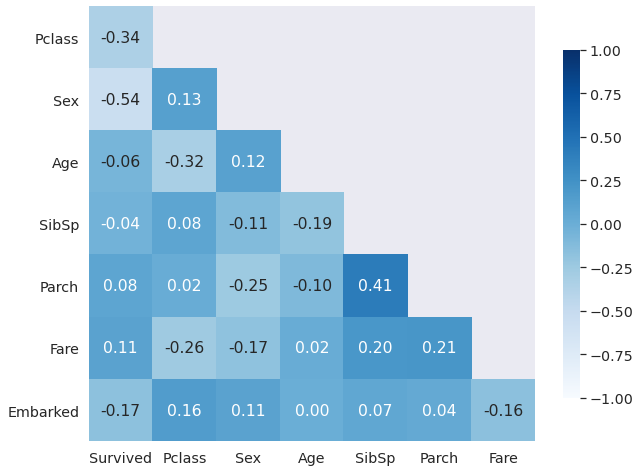

In [34]:
corr = train.corr()
fig, ax = plt.subplots(figsize=(10, 8))# mask
mask = np.triu(np.ones_like(corr, dtype=np.bool))# adjust mask and df
mask = mask[1:, :-1]
corr = corr.iloc[1:,:-1].copy()# plot heatmap
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='Blues', vmin=-1, vmax=1, cbar_kws={"shrink": .8})# yticks
plt.yticks(rotation=0)
plt.show()

<a id="4"></a>
# <div style="text-align: center; background-color:#319bad; font-family:newtimeroman; color: white; padding: 14px; line-height: 1;border-radius:20px">4. Model</div>

In [35]:
x = train.drop(['Survived','FareBand','AgeBand'], axis=1)
y = train.iloc[:,0]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y)

In [36]:
mod = []
acc = []
kb = []

<div style="color:black; background-color:#f5f7b0; border-radius:10px; padding:20px;">
Loop to fetch the best value of K 
</div>

In [37]:
i = 1

while i < 8:
    x_new = SelectKBest(chi2, k=i).fit_transform(x, y)
    x_train, x_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, stratify=y)
    model = GradientBoostingClassifier()
    model.fit(x_train, y_train)
    vl = cross_val_score(model, x_test,y_test, cv=10, n_jobs=-1)
    mod.append('GradientBoostingClassifier')
    acc.append(round((vl.mean()*100),2))
    kb.append(i)

    model = ExtraTreesClassifier()
    model.fit(x_train, y_train)
    vl = cross_val_score(model, x_test,y_test, cv=10, n_jobs=-1)
    mod.append('ExtraTreesClassifier')
    acc.append(round((vl.mean()*100),2))
    kb.append(i)

    model = BaggingClassifier()
    model.fit(x_train, y_train)
    vl = cross_val_score(model, x_test,y_test, cv=10, n_jobs=-1)
    mod.append('BaggingClassifier')
    acc.append(round((vl.mean()*100),2))
    kb.append(i)

    model = RandomForestClassifier(n_estimators=100)
    model.fit(x_train, y_train)
    vl = cross_val_score(model, x_test,y_test, cv=10, n_jobs=-1)
    mod.append('RandomForestClassifier')
    acc.append(round((vl.mean()*100),2))
    kb.append(i)

    model = DecisionTreeClassifier()
    model.fit(x_train, y_train)
    vl = cross_val_score(model, x_test,y_test, cv=10, n_jobs=-1)
    mod.append('DecisionTreeClassifier')
    acc.append(round((vl.mean()*100),2))
    kb.append(i)

    model = ExtraTreeClassifier()
    model.fit(x_train, y_train)
    vl = cross_val_score(model, x_test,y_test, cv=10, n_jobs=-1)
    mod.append('ExtraTreeClassifier')
    acc.append(round((vl.mean()*100),2))
    kb.append(i)

    model = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1)
    model.fit(x_train, y_train, eval_metric='auc')
    vl = cross_val_score(model, x_test,y_test, cv=10, n_jobs=-1)
    mod.append('XGBClassifier')
    acc.append(round((vl.mean()*100),2))
    kb.append(i)
    
    i += 1

In [38]:
df_result = pd.DataFrame()
df_result['model'] = mod
df_result['acc'] = acc
df_result['kbest'] = kb
df_result.sort_values(by=['acc'], ascending=False).head()

,model,acc,kbest
42,GradientBoostingClassifier,83.27,7
46,DecisionTreeClassifier,83.24,7
45,RandomForestClassifier,82.16,7
44,BaggingClassifier,82.16,7
43,ExtraTreesClassifier,80.98,7


<a id="5"></a>
# <div style="text-align: center; background-color:#319bad; font-family:newtimeroman; color: white; padding: 14px; line-height: 1;border-radius:20px">5. AutoML</div>

In [39]:
import h2o
from h2o.automl import H2OAutoML

#from h2o.estimators.gbm import H2OGradientBoostingEstimator

h2o.init()
h2o.cluster().show_status()

treino_h2o = h2o.H2OFrame(train)

# convert response column to a factor
treino_h2o["Survived"] = treino_h2o["Survived"].asfactor()

# set the predictor names and the response column name
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
response = "Survived"

# split into train and validation sets
train_h2, valid_h2 = treino_h2o.split_frame(ratios = [.8])

# try using the `y` parameter:
# first initialize your estimator
cars_gbm = H2OAutoML(max_models=10, max_runtime_secs=1800)

# then train your model, where you specify your 'x' predictors, your 'y' the response column
# training_frame and validation_frame
cars_gbm.train(x = predictors, y = response, training_frame = train_h2, validation_frame = valid_h2)

# print the auc for the validation data
lb = cars_gbm.leaderboard
lb.head(rows=lb.nrows) 

Checking whether there is an H2O instance running at http://localhost:54321 ..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.10" 2021-01-19; OpenJDK Runtime Environment (build 11.0.10+9-Ubuntu-0ubuntu1.18.04); OpenJDK 64-Bit Server VM (build 11.0.10+9-Ubuntu-0ubuntu1.18.04, mixed mode, sharing)
  Starting server from /opt/conda/lib/python3.7/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpijzrf8lg
  JVM stdout: /tmp/tmpijzrf8lg/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpijzrf8lg/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.32.0.4
H2O_cluster_version_age:,"1 year, 11 months and 1 day !!!"
H2O_cluster_name:,H2O_from_python_unknownUser_4keyb2
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.840 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"accepting new members, healthy"


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.32.0.4
H2O_cluster_version_age:,"1 year, 11 months and 1 day !!!"
H2O_cluster_name:,H2O_from_python_unknownUser_4keyb2
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.840 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"accepting new members, healthy"


Parse progress: |█████████████████████████████████████████████████████████| 100%
AutoML progress: |
23:55:05.622: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.

████████████████████████████████████████████████████████| 100%


model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
GBM_3_AutoML_20230102_235505,0.86144,0.43405,0.839048,0.200222,0.368735,0.135965
GBM_2_AutoML_20230102_235505,0.860145,0.437156,0.832986,0.198727,0.369514,0.136541
GBM_4_AutoML_20230102_235505,0.859214,0.437357,0.833146,0.208357,0.370348,0.137157
StackedEnsemble_AllModels_AutoML_20230102_235505,0.855445,0.434426,0.832245,0.206311,0.369271,0.136361
StackedEnsemble_BestOfFamily_AutoML_20230102_235505,0.854174,0.437831,0.834007,0.204069,0.371657,0.138129
XGBoost_3_AutoML_20230102_235505,0.85357,0.446679,0.825647,0.208957,0.373767,0.139702
XGBoost_1_AutoML_20230102_235505,0.853096,0.441195,0.829123,0.198221,0.370436,0.137223
GBM_1_AutoML_20230102_235505,0.852472,0.451355,0.818088,0.207271,0.377793,0.142728
XGBoost_2_AutoML_20230102_235505,0.842544,0.452026,0.817854,0.213964,0.377377,0.142413
GLM_1_AutoML_20230102_235505,0.839848,0.465005,0.816773,0.215598,0.384432,0.147788


![Upvote!](https://img.shields.io/badge/Upvote-If%20you%20like%20my%20work-07b3c8?style=for-the-badge&logo=kaggle)